In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.table as tbl

In [2]:
data = []
with open("strategy_comparison.csv", "r") as f:
    f.readline()
    for line in f:
        data.append(map(float, line.strip().split(",")))

shannon_guesses, shannon_times, knuth_wc_guesses, knuth_wc_times, knuth_avg_guesses, knuth_avg_times = zip(*data)


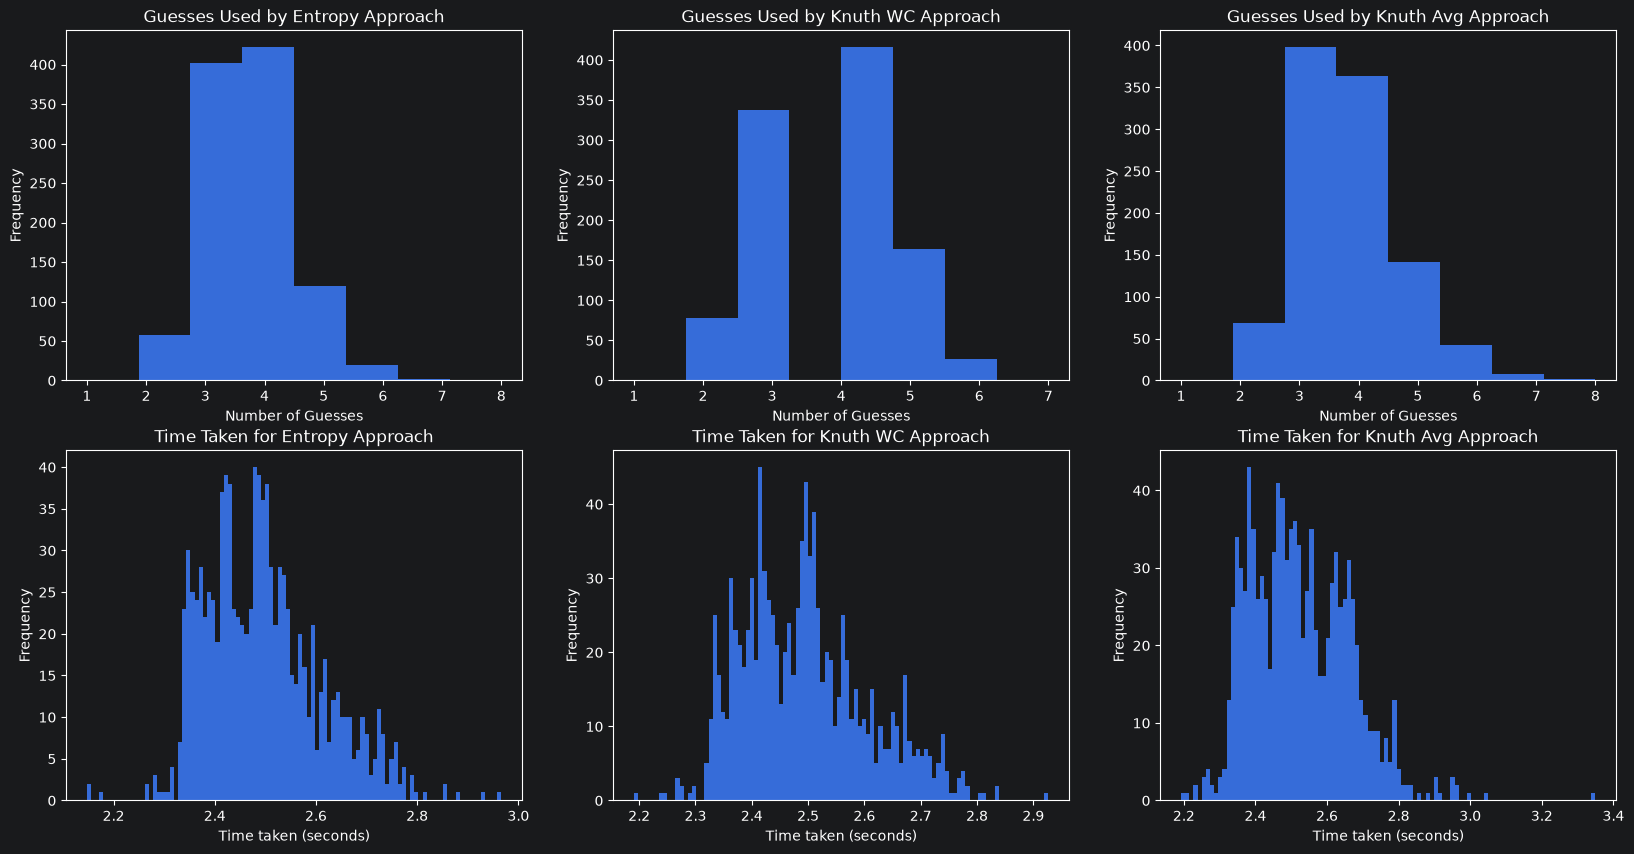

In [5]:
fig, axs = plt.subplots(2, 3)
fig.set_size_inches(20, 10)
for c, (name, num_guesses, times) in enumerate([("Entropy", shannon_guesses, shannon_times), ("Knuth WC", knuth_wc_guesses, knuth_wc_times), ("Knuth Avg", knuth_avg_guesses, knuth_avg_times)]):
    axs[0,c].hist(num_guesses, bins=8)
    axs[0,c].set_title(f"Guesses Used by {name} Approach")
    axs[0,c].set_xlabel("Number of Guesses")
    axs[0,c].set_ylabel("Frequency")

    axs[1,c].hist(times, bins=100)
    axs[1,c].set_title(f"Time Taken for {name} Approach")
    axs[1,c].set_xlabel("Time taken (seconds)")
    axs[1,c].set_ylabel("Frequency")

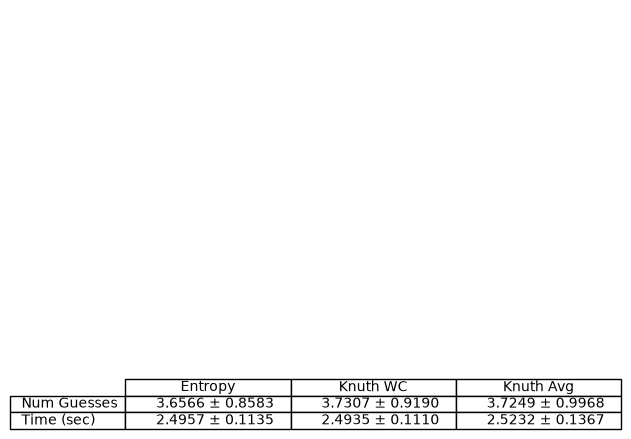

In [44]:
table_fig, table_axis = plt.subplots(1)

table_data = [
    [
        f"{np.mean(shannon_guesses):.4f} \u00B1 {np.std(shannon_guesses):.4f}",
        f"{np.mean(knuth_wc_guesses):.4f} \u00B1 {np.std(knuth_wc_guesses):.4f}",
        f"{np.mean(knuth_avg_guesses):.4f} \u00B1 {np.std(knuth_avg_guesses):.4f}"
    ],
    [
        f"{np.mean(shannon_times):.4f} \u00B1 {np.std(shannon_times):.4f}",
        f"{np.mean(knuth_wc_times):.4f} \u00B1 {np.std(knuth_wc_times):.4f}",
        f"{np.mean(knuth_avg_times):.4f} \u00B1 {np.std(knuth_avg_times):.4f}"
    ]
]

columns = ["Entropy", "Knuth WC", "Knuth Avg"]
rows = ["Num Guesses", "Time (sec)"]


tbl.table(table_axis, cellText=table_data, rowLabels=rows, colLabels=columns)
table_axis.set_axis_off()


In [37]:
plt.show()

In [4]:

wins = [0, 0, 0]
ties = [0, 0, 0]
for i in range(len(shannon_guesses)):
    a, b, c = shannon_guesses[i], knuth_wc_guesses[i], knuth_avg_guesses[i]

    if a == b and a == c:
        ties[0] += 1
        ties[1] += 1
        ties[2] += 1

    elif a == b:
        ties[0] += 1
        ties[1] += 1

    elif a == c:
        ties[0] += 1
        ties[2] += 1

    elif b == c:
        ties[1] += 1
        ties[2] += 1

    elif a < b and a < c:
        wins[0] += 1
    elif b < c:
        wins[1] += 1
    else:
        wins[2] += 1

print(wins)
print(ties)

[65, 34, 26]
[713, 744, 619]
